In [1]:
EXP_NAME="1MAY"
N = 20000
n_test = 1000
n_train = 800
seed = 4
minority_perc = 0.4
prevalence = 0.10
min_age = 35
max_age = 85
mean_age = 65
std_age = 12

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

# Generate the clinical ground truth

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm, gamma, beta, truncnorm
from scipy.special import expit
from scipy.optimize import bisect
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import class_balanced_sampling, proportion_preserving_sampling, scale_dataset, plot_cat_feature, plot_cont_feature

In [4]:
def generate_truncated_age(n_pop, low=min_age, high=max_age, mu=mean_age, sigma=std_age):
  # Convert absolute bounds to standard deviation units
  a_std = (low - mu) / sigma
  b_std = (high - mu) / sigma
  
  # Generate the distribution
  age = truncnorm.rvs(a_std, b_std, loc=mu, scale=sigma, size=n_pop)
  
  return age.round(0)

age = generate_truncated_age(n_pop=N)

In [5]:
def generate_latent_health(n_pop, S, age, seed=42):
  """ 
  Generates the latent health state of the population, underlying cause of the outcome
  """
  np.random.seed(seed)
  
  # GENETIC MARKERS:
  # Genetic marker 1
  # Count of risk alleles (0, 1, 2)
  # Minor Allele Frequency (MAF) differs by ancestry proxy (S)
  maf = np.where(S == 0, 0.38, 0.12)
  genetic_marker_1 = np.random.binomial(2, maf, n_pop)

  # Genetic marker 2
  # Presence of rare mutation increasing risk of the outcome, independend of S
  genetic_marker_2 = np.random.binomial(1, 0.05, n_pop)
  
  # LATENTS 'pathology' drive both clinical manifestations and the target outcome
  # Health latent, independent of S, influenced by Age and genetic marker 2
  age_std = (age - 65) /12
  gen_effect_h = (genetic_marker_2 - np.mean(genetic_marker_2))
  health_raw = gamma.rvs(a=1.5, scale=1.0, size=n_pop)
  health_latent = 0.5 * age_std + 1.5 * gen_effect_h + health_raw

  # Latent 1
  # Influenced by health latent, biological S, and genetic marker 1
  latent_corr_raw = gamma.rvs(a=1.2, scale=1.0, size=n_pop)
  latent_corr = health_latent + np.where(S == 0, 0.5, 1.5) * latent_corr_raw
  
  # Latent 2
  # Only influenced by health latent
  latent_desc_raw = gamma.rvs(a=1.2, scale=1.0, size=n_pop)
  latent_desc = health_latent + latent_desc_raw

  return health_latent, latent_corr, latent_desc, genetic_marker_1, genetic_marker_2


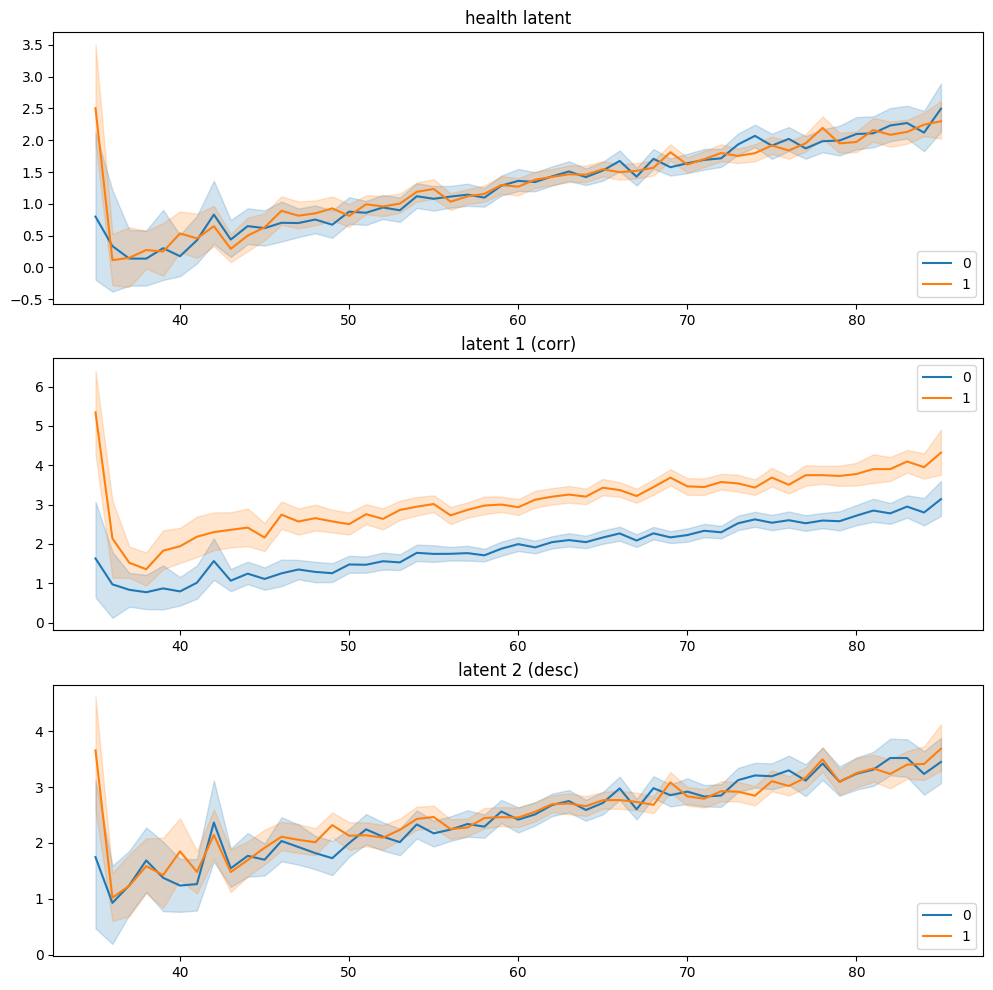

In [6]:
S = np.random.binomial(1, 1 - minority_perc, N)

health_latent, latent_corr, latent_desc, genetic_marker_1, genetic_marker_2 = generate_latent_health(N, S, age)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
sns.lineplot(x=age, y=health_latent, estimator="mean", hue=S, ax=axes[0])
sns.lineplot(x=age, y=latent_corr, estimator="mean", hue=S, ax=axes[1])
sns.lineplot(x=age, y=latent_desc, estimator="mean", hue=S, ax=axes[2])
axes[0].set_title("health latent")
axes[1].set_title("latent 1 (corr)")
axes[2].set_title("latent 2 (desc)")
plt.show()

In [7]:

def generate_clinical_ground_truth(n_pop, latent_corr, latent_desc, seed=42):
    """
    Generates unbiased health states and legitimate correlations.
    """
    np.random.seed(seed)

    # ---- CLINICAL OUTCOME (Only influenced by Latents) ---
    # Intercept tuned to pre-defined prevalence
    def find_intercept(latent_signal, target_prevalence):
      """
      Finds the intercept beta0 such that mean(expit(beta0 + latent_signal)) == target_prevalence
      """
      def objective(beta0):
        return np.mean(expit(beta0 + latent_signal)) - target_prevalence
      
      return bisect(objective, -20, 0)

    beta0 = find_intercept(latent_corr + latent_desc, prevalence)
    logits = beta0 + latent_corr + latent_desc
    outcome_Y = np.random.binomial(1, expit(logits), n_pop)
    
    # ---- UNBIASED FEATURES INDEPENDENT FROM S, manifestations of the Latent Desc ----

    # Symptom 1: Ordinal [0-4], skewed right
    s1_base_p = np.array([0.45, 0.30, 0.15, 0.07, 0.03])
    s1_weights = np.exp(np.outer(latent_desc, np.arange(5) * 0.4)) * s1_base_p
    s1_probs = s1_weights / s1_weights.sum(axis=1, keepdims=True)
    symptom_1 = np.array([np.random.choice([0, 1, 2, 3, 4], p=p) for p in s1_probs])
    
    # Symptom 2: Categorical [0, 1, 2], correlated with outcome via latent pathology
    # f0 (Healthy/Normal): High baseline, drops off quickly as pathology increases
    f0 = 1.2 - 1.8 * latent_desc 
    # f1 (Mild/Atypical): Moderate baseline, relatively stable across pathology
    f1 = 0.5 - 0.2 * latent_desc 
    # f2 (Severe/Specific): Low baseline, increases sharply with pathology
    f2 = -1.5 + 1.5 * latent_desc 
    s2_logits = np.column_stack([f0, f1, f2])
    s2_probs = np.exp(s2_logits) / np.sum(np.exp(s2_logits), axis=1, keepdims=True)
    symptom_2 = np.array([np.random.choice([0, 1, 2], p=p) for p in s2_probs])

    # Biomarker 1: Normal distribution
    biomarker_1 = np.random.normal(100 + 8 * latent_desc, 15, n_pop)
    
    # Biomarker 2: Skewed right continuous (e.g., Enzyme levels)
    alpha_b2 = np.maximum(0.5, 2.0 + 0.7 * latent_desc)
    biomarker_2 = gamma.rvs(a=alpha_b2, scale=10, size=n_pop)
    
    # Risk score for procedure: Continuous, skewed left
    alpha_risk = np.maximum(0.5, 1.0 + 0.7 * latent_desc)
    risk_score_proc = gamma.rvs(a=alpha_risk, scale=1, size=n_pop)

    # ---- FEATURES CORRELATED WITH S (fair bias) ----

    # Symptom 3: Binary, prevalence depends on sensitive attribute S
    p3_logits = -10 + 3 * latent_corr
    symptom_3 = np.random.binomial(1, expit(p3_logits), n_pop)

    # Symptom 4: Categorical [0, 1, 2], group-specific proportions
    s4_f0 = np.where(S == 0, 1.0, 0.8) - 0.2 * latent_corr
    s4_f1 = np.where(S == 0, -0.1, -0.3) + 0.4 * latent_corr
    s4_f2 = np.where(S == 0, -2, -1) + 0.3 * latent_corr
    s4_logits = np.column_stack([s4_f0, s4_f1, s4_f2])
    s4_probs = np.exp(s4_logits) / np.sum(np.exp(s4_logits), axis=1, keepdims=True)
    symptom_4 = np.array([np.random.choice([0, 1, 2], p=p) for p in s4_probs])

    # Biomarker 3: Normal, group-specific means
    biomarker_3 = 40 + 15*S + 5*latent_corr + np.random.normal(0, 10, n_pop)
    
    return pd.DataFrame({
      'symptom_1': symptom_1,
      'symptom_2': symptom_2, 
      'biomarker_1': biomarker_1,
      'biomarker_2': biomarker_2, 
      'risk_score_proc': risk_score_proc,
      'symptom_3': symptom_3, 
      'symptom_4': symptom_4,
      'biomarker_3': biomarker_3, 
      'outcome_Y': outcome_Y
    })

# Initialize the unbiased dataset
unbiased_pop = generate_clinical_ground_truth(N, latent_corr, latent_desc)
unbiased_pop["S"] = S
unbiased_pop["age"] = age
unbiased_pop["genetic_marker_1"] = genetic_marker_1
unbiased_pop["genetic_marker_2"] = genetic_marker_2
unbiased_pop
# Verification of AFib Prevalence
print(f"Baseline Outcome Prevalence: {unbiased_pop['outcome_Y'].mean():.2%}")

import os
data_dir = f"{PROJECT_ROOT}/data/synth/{EXP_NAME}"
os.makedirs(data_dir, exist_ok=True)

unbiased_pop.to_csv(f'{data_dir}/unbiased_raw.csv', index=False)



Baseline Outcome Prevalence: 10.18%


In [8]:
from tableone import TableOne

# Descriptive statistics
table1 = TableOne(unbiased_pop,
                  groupby='S',
                  continuous=['age','symptom_1','biomarker_1','biomarker_2','biomarker_3', 'risk_score_proc'],
                  categorical=['outcome_Y','genetic_marker_1', 'genetic_marker_2', 'symptom_2','symptom_3', 'symptom_4'],
                  missing=False,
                  sort=True
                  )

print("Population statistical summary")
print("="*80)
print(table1)

Population statistical summary
                              Grouped by S                            
                                   Overall             0             1
n                                    20000          7913         12087
age, mean (SD)                 63.9 (10.6)   63.8 (10.7)   63.9 (10.5)
biomarker_1, mean (SD)        121.3 (20.5)  121.1 (20.7)  121.4 (20.4)
biomarker_2, mean (SD)         38.5 (23.0)   38.4 (23.4)   38.5 (22.8)
biomarker_3, mean (SD)         62.8 (17.1)   50.1 (12.4)   71.2 (14.4)
genetic_marker_1, n (%)    0  12408 (62.0)   3040 (38.4)   9368 (77.5)
                           1   6282 (31.4)   3733 (47.2)   2549 (21.1)
                           2    1310 (6.6)   1140 (14.4)     170 (1.4)
genetic_marker_2, n (%)    0  19008 (95.0)   7521 (95.0)  11487 (95.0)
                           1     992 (5.0)     392 (5.0)     600 (5.0)
outcome_Y, n (%)           0  17964 (89.8)   7372 (93.2)  10592 (87.6)
                           1   2036 (10.2)    

# Sampling (unbiased)

In [9]:
unbiased_pop['age_bin'] = pd.qcut(unbiased_pop['age'], q=10, labels=False)

In [10]:
unbiased_train, unbiased_test = proportion_preserving_sampling(
  unbiased_pop, 
  ['S', 'age_bin', 'outcome_Y'], 
  n_train, n_test, seed)

unbiased_bal_train, unbiased_bal_test = class_balanced_sampling(
  unbiased_pop, 
  "outcome_Y",
  ['S', 'age_bin'],
  n_train, n_test, seed)

unbiased_train.drop(columns=['age_bin'], inplace=True)
unbiased_test.drop(columns=['age_bin'], inplace=True)
unbiased_bal_train.drop(columns=['age_bin'], inplace=True)
unbiased_bal_test.drop(columns=['age_bin'], inplace=True)
unbiased_pop.drop(columns=['age_bin'], inplace=True) 

print("=== Unbiased dataset, proportion-preserving sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(unbiased_train)}")
print(f"Prevalence in Training set: {unbiased_train['outcome_Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(unbiased_test)}")
print(f"Prevalence in Test set: {unbiased_test['outcome_Y'].mean():.2%}")

print("=== Unbiased dataset, class-balanced sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(unbiased_bal_train)}")
print(f"Prevalence in Training set: {unbiased_bal_train['outcome_Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(unbiased_bal_test)}")
print(f"Prevalence in Test set: {unbiased_bal_test['outcome_Y'].mean():.2%}")

=== Unbiased dataset, proportion-preserving sampling ===
Target Train size: 800 | Actual size: 818
Prevalence in Training set: 11.00%
Target Test size: 1000 | Actual size: 1019
Prevalence in Test set: 10.99%
=== Unbiased dataset, class-balanced sampling ===
Target Train size: 800 | Actual size: 794
Prevalence in Training set: 49.87%
Target Test size: 1000 | Actual size: 993
Prevalence in Test set: 49.85%


## Distributions

## S-independent features

=== Proportion-preserving sampling ===


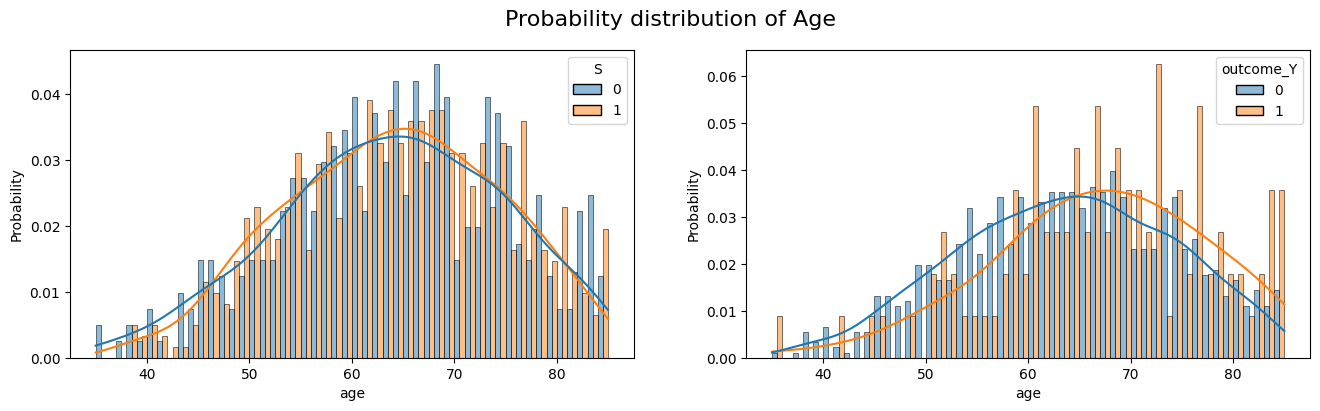

=== Class-balanced sampling ===


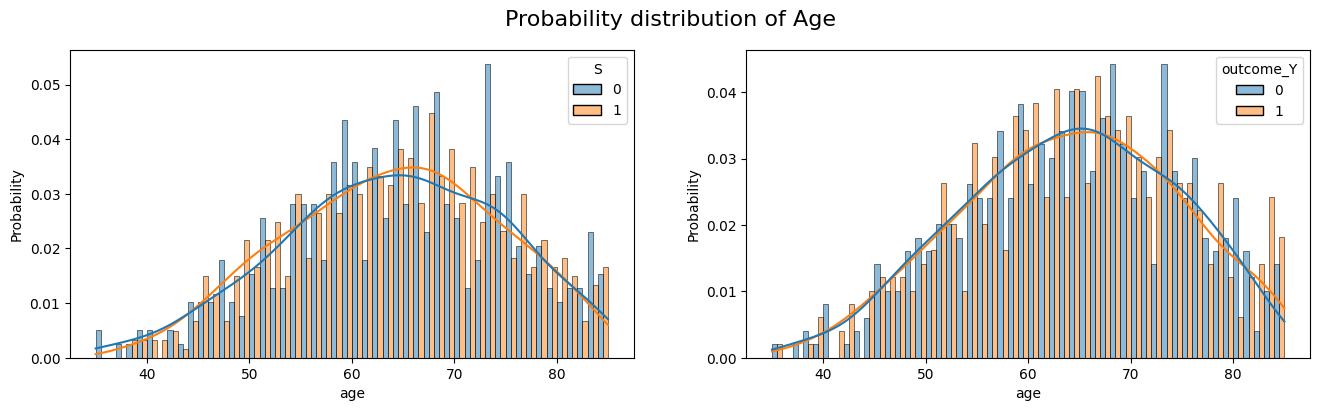

In [11]:
# Age
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'age', "Age", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'age', "Age", "outcome_Y")

=== Proportion-preserving sampling ===


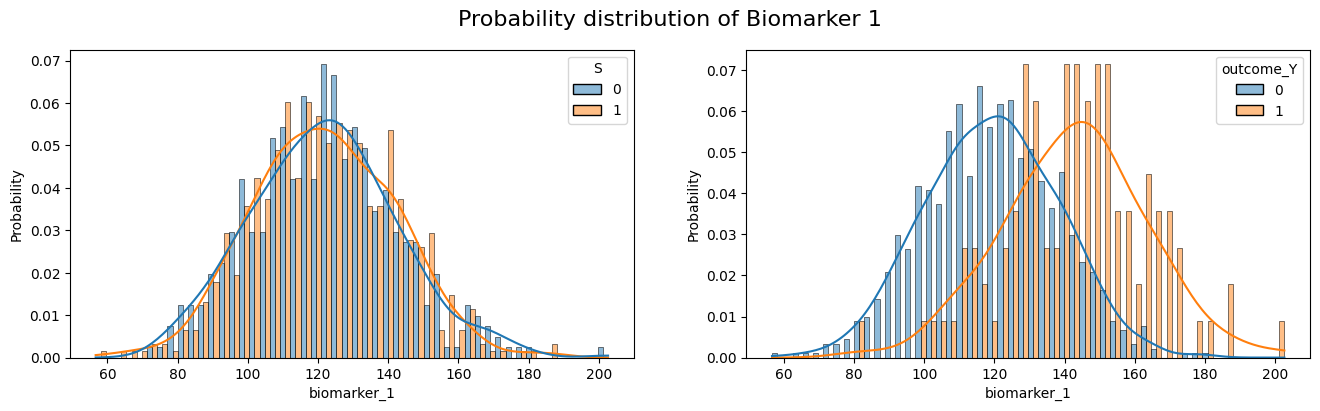

=== Class-balanced sampling ===


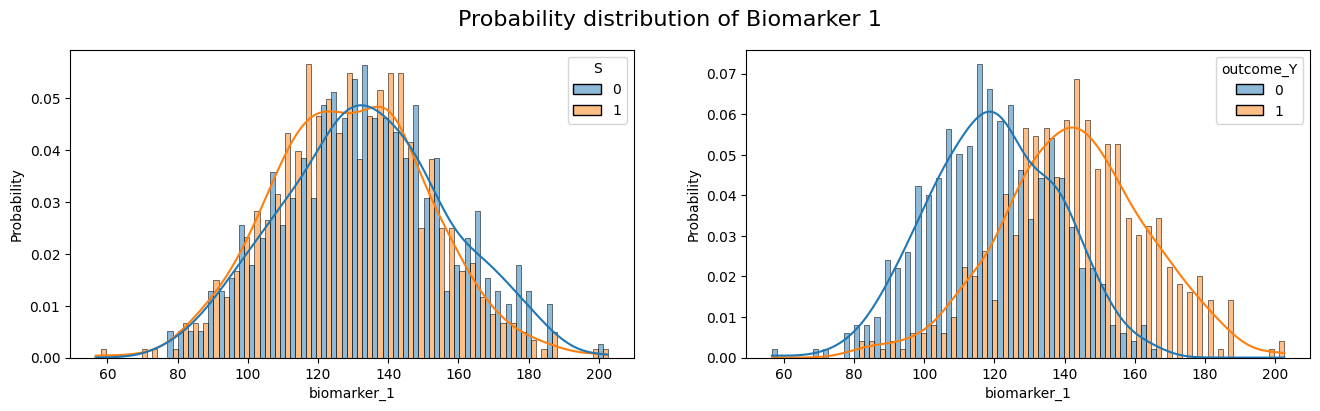

In [12]:
# Biomarker 1
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_1', "Biomarker 1", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_1', "Biomarker 1", "outcome_Y")

=== Proportion-preserving sampling ===


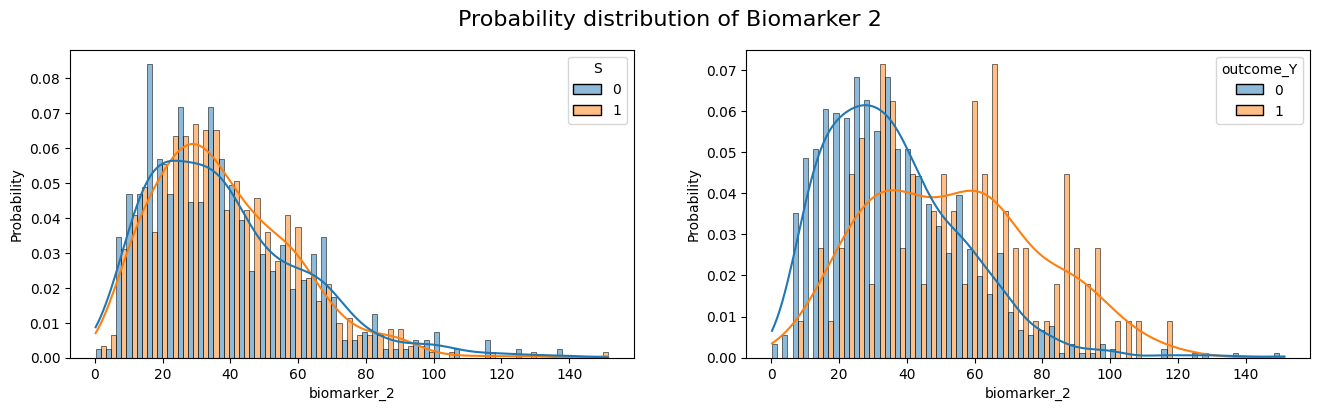

=== Class-balanced sampling ===


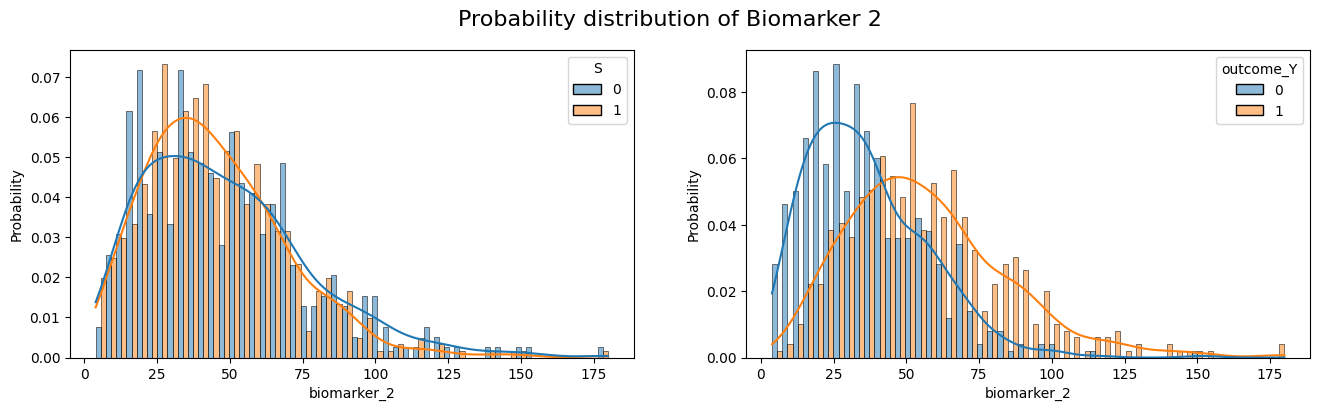

In [13]:
# Biomarker 2
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_2', "Biomarker 2", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_2', "Biomarker 2", "outcome_Y")

=== Proportion-preserving sampling ===


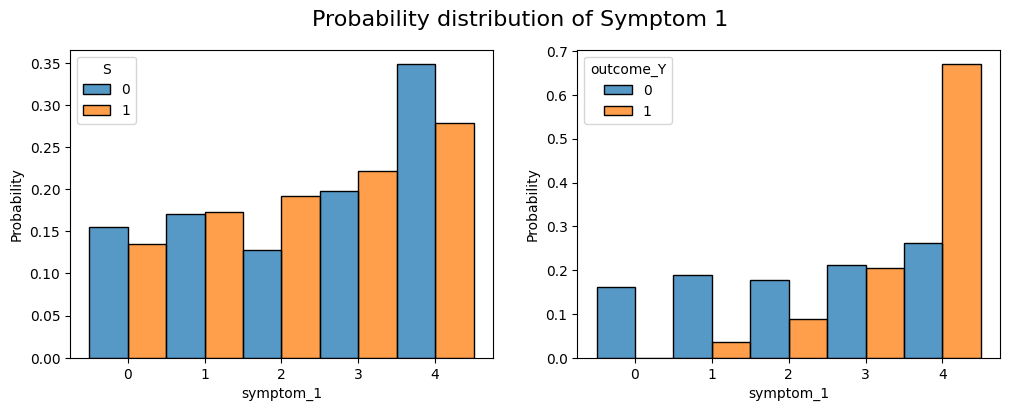

=== Class-balanced sampling ===


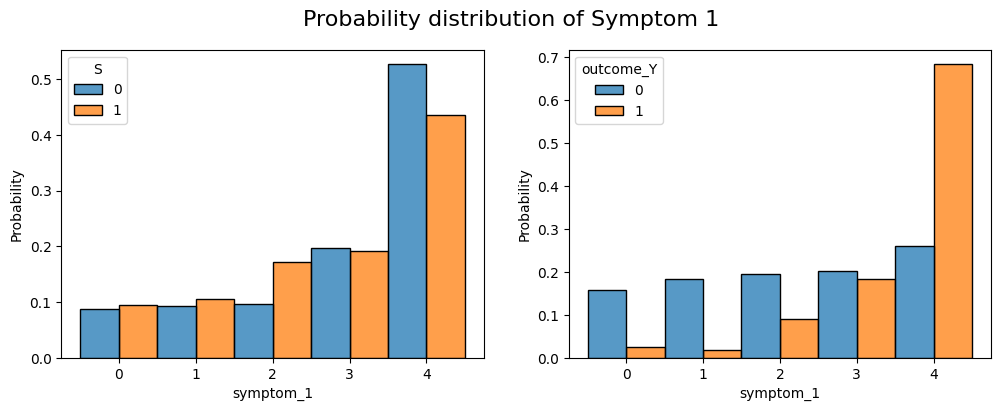

In [14]:
# Symptom 1
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'symptom_1', "Symptom 1", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'symptom_1', "Symptom 1", "outcome_Y")

=== Proportion-preserving sampling ===


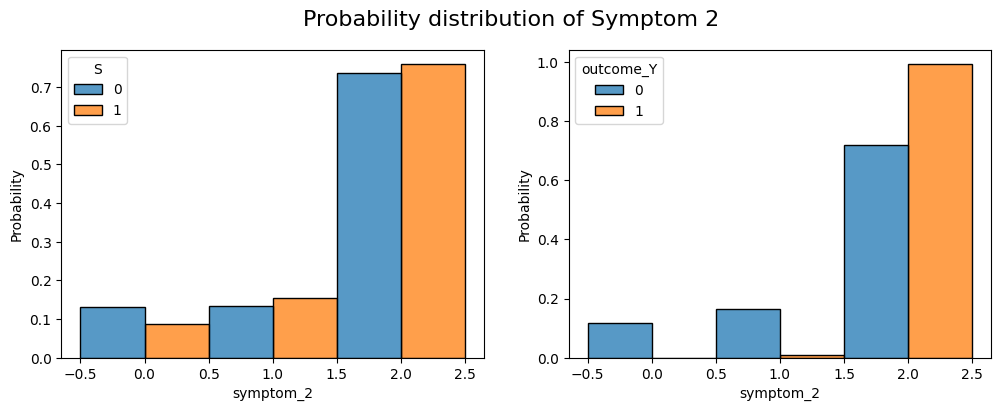

=== Class-balanced sampling ===


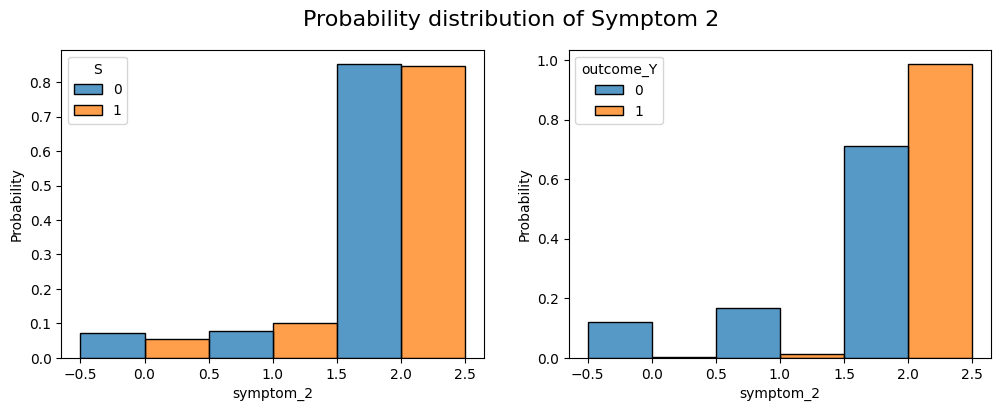

In [15]:
# Symptom 2
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'symptom_2', "Symptom 2", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'symptom_2', "Symptom 2", "outcome_Y")

=== Proportion-preserving sampling ===


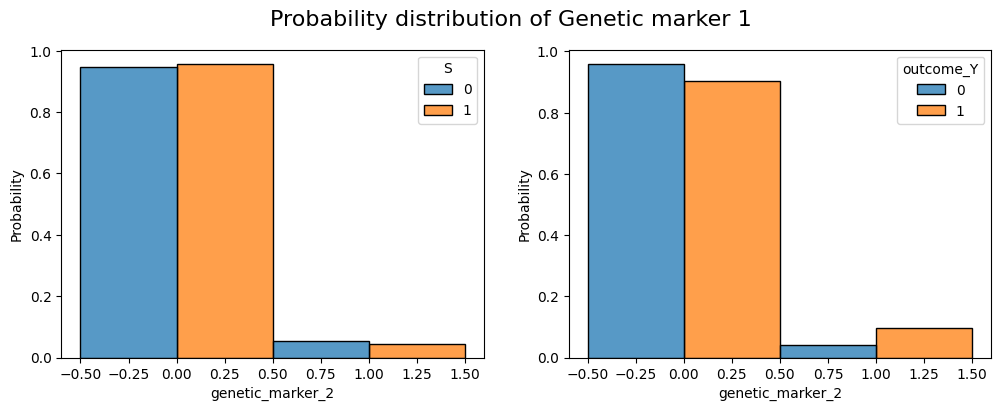

=== Class-balanced sampling ===


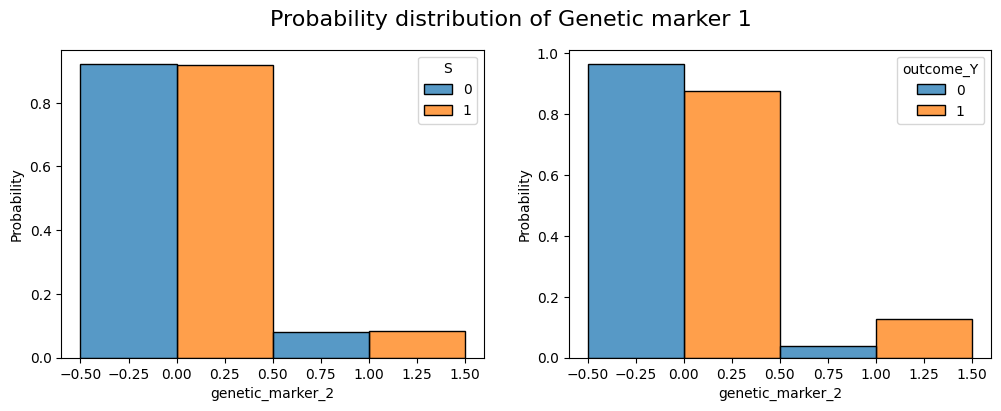

In [16]:
# Genetic marker 2
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'genetic_marker_2', "Genetic marker 1", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'genetic_marker_2', "Genetic marker 1", "outcome_Y")


=== Proportion-preserving sampling ===


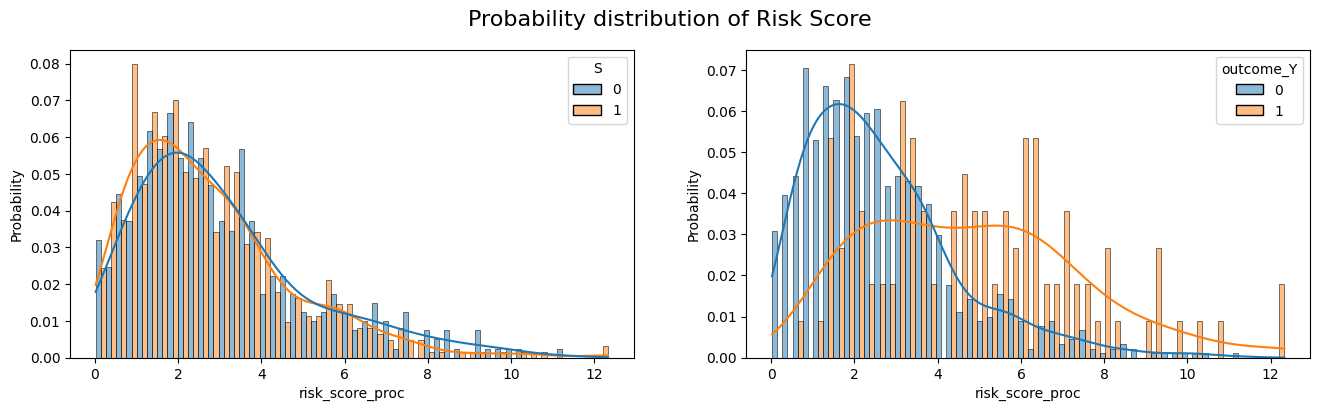

=== Class-balanced sampling ===


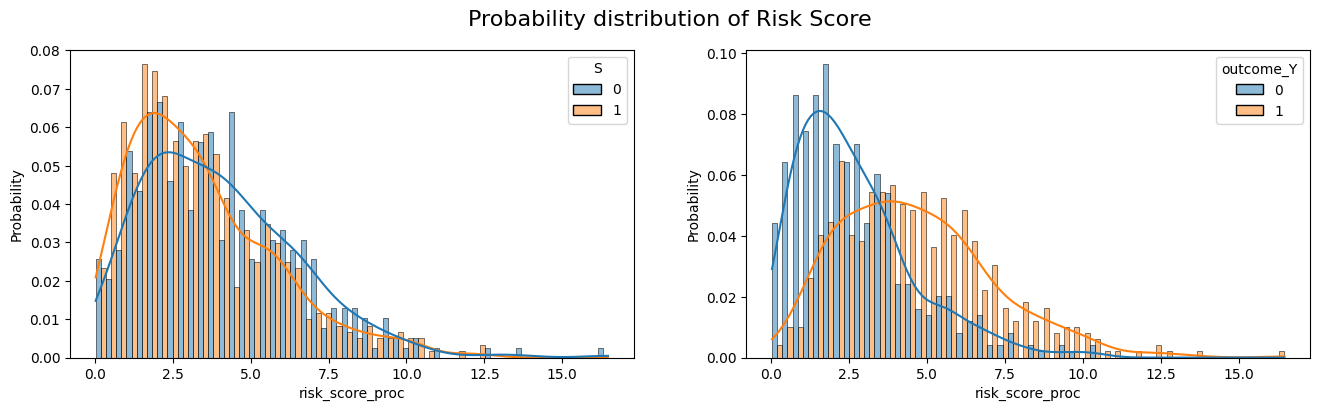

In [17]:
# Risk Score
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'risk_score_proc', "Risk Score", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'risk_score_proc', "Risk Score", "outcome_Y")


## S-correlated features

=== Proportion-preserving sampling ===


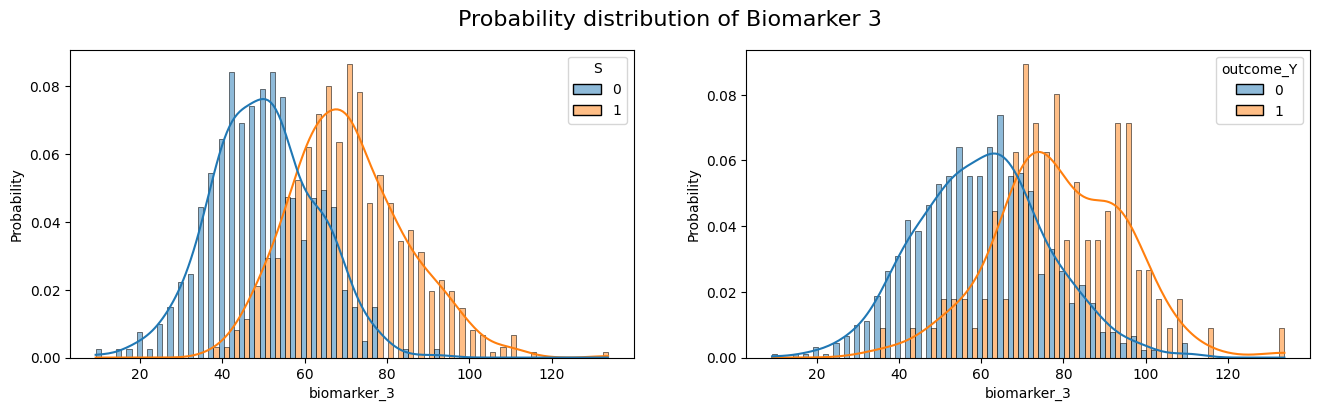

=== Class-balanced sampling ===


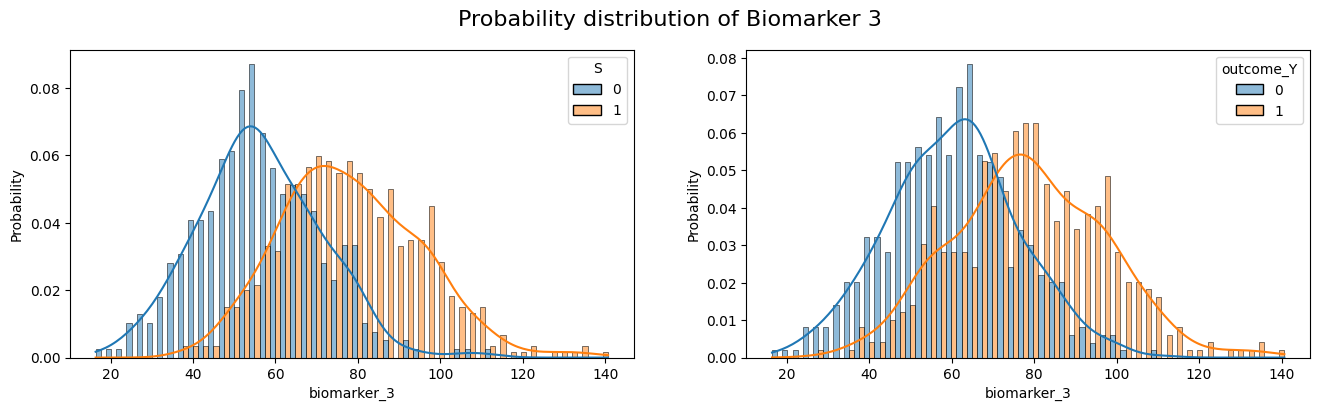

In [18]:
# Biomarker 3
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_3', "Biomarker 3", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_3', "Biomarker 3", "outcome_Y")

=== Proportion-preserving sampling ===


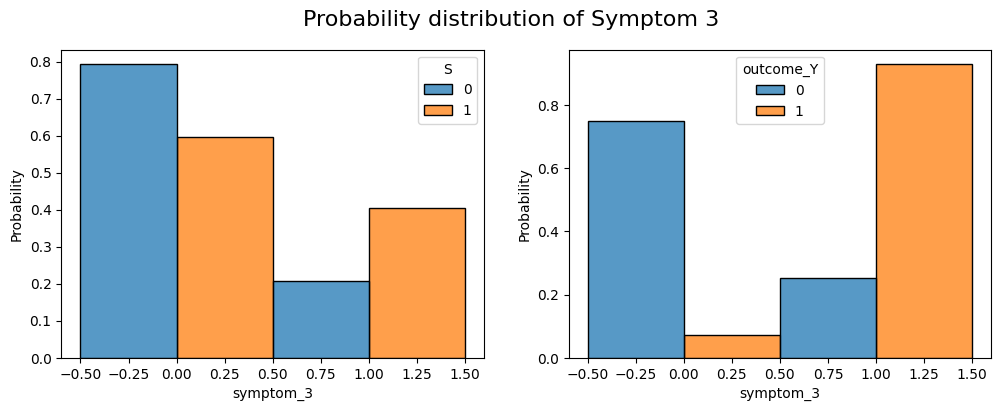

=== Class-balanced sampling ===


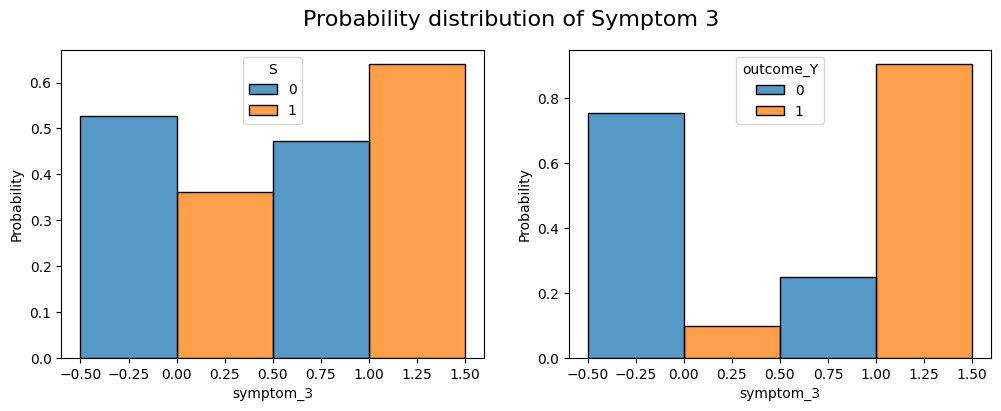

In [19]:
# Symptom 3
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'symptom_3', "Symptom 3", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'symptom_3', "Symptom 3", "outcome_Y")

=== Proportion-preserving sampling ===


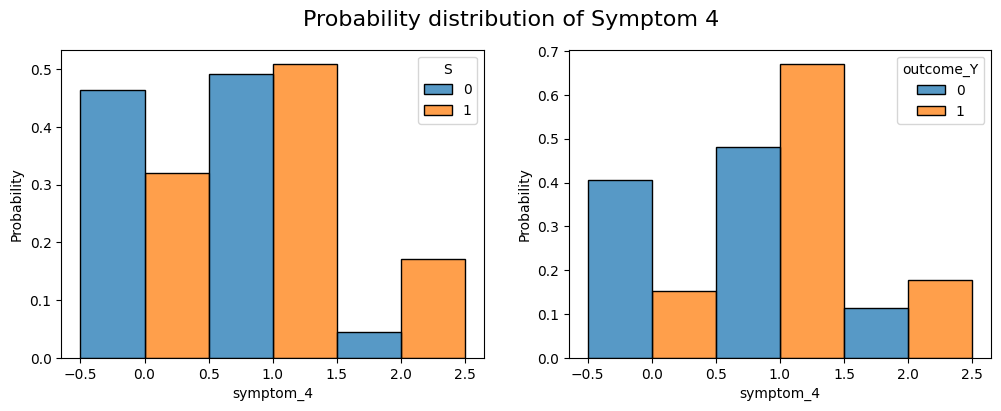

=== Class-balanced sampling ===


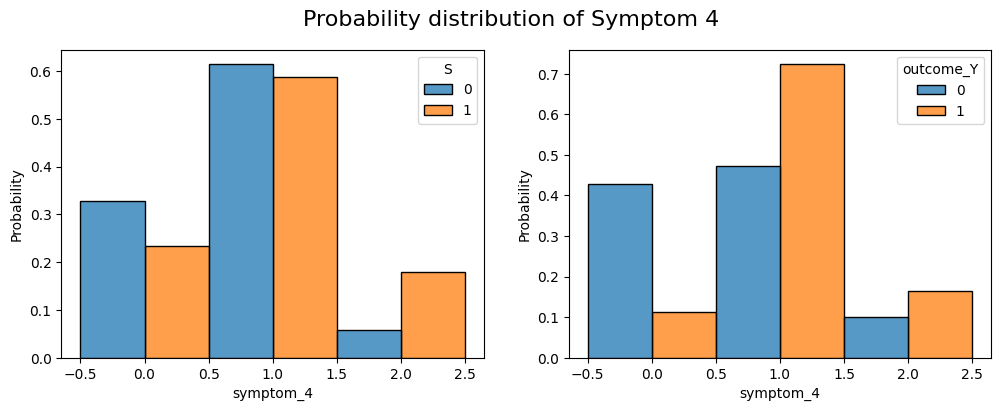

In [20]:
# Symptom 4
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'symptom_4', "Symptom 4", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'symptom_4', "Symptom 4", "outcome_Y")

=== Proportion-preserving sampling ===


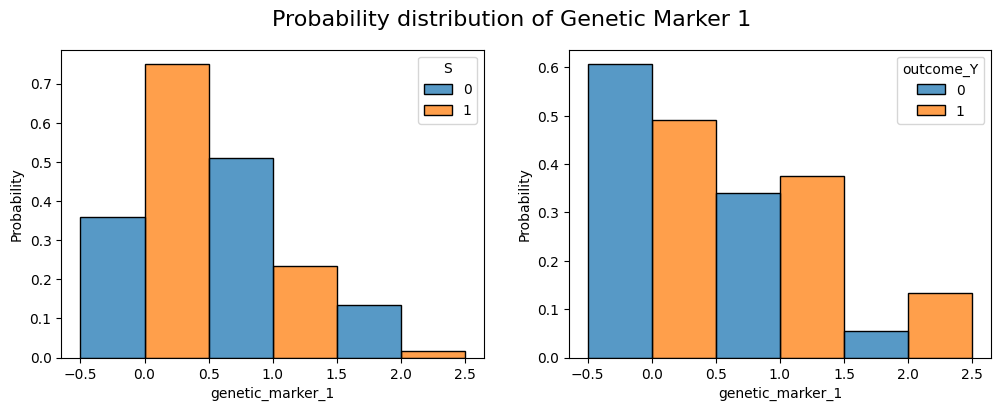

=== Class-balanced sampling ===


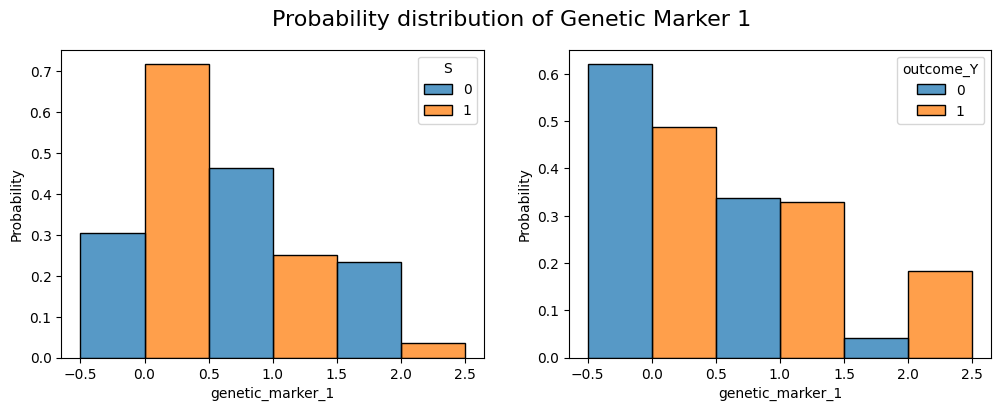

In [21]:
# Genetic marker 1
print("=== Proportion-preserving sampling ===")
fig = plot_cat_feature(unbiased_test, 'genetic_marker_1', "Genetic Marker 1", "outcome_Y")
print("=== Class-balanced sampling ===")
fig = plot_cat_feature(unbiased_bal_test, 'genetic_marker_1', "Genetic Marker 1", "outcome_Y")


# Processing

In [22]:
norm_variables = ['age', "biomarker_1", "biomarker_3"]
skewed_variables = ["biomarker_2"]

unbiased_train_processed = scale_dataset(unbiased_train, norm_variables, skewed_variables)
unbiased_test_processed = scale_dataset(unbiased_test, norm_variables, skewed_variables)
unbiased_classbal_train_processed = scale_dataset(unbiased_bal_train, norm_variables, skewed_variables)
unbiased_classbal_test_processed = scale_dataset(unbiased_bal_test, norm_variables, skewed_variables)

unbiased_train_processed.to_csv(f'{data_dir}/unbiased_test.csv', index=False)
unbiased_test_processed.to_csv(f'{data_dir}/unbiased_train.csv', index=False)
unbiased_classbal_train_processed.to_csv(f'{data_dir}/unbiased_classbal_train.csv', index=False)
unbiased_classbal_test_processed.to_csv(f'{data_dir}/unbiased_classbal_test.csv', index=False)